# Inżynieria danych

Przykład na zbiorze: https://www.kaggle.com/datasets/kiva/data-science-for-good-kiva-crowdfunding?select=kiva_loans.csv

In [18]:
import pandas as pd
import matplotlib.pyplot as plt

In [19]:
dane = pd.read_csv('kiva_loans.csv', sep=',', decimal='.', encoding='utf-8')

### Informacje o danych

In [20]:
print(dane.head(),"\n\n")
print(dane.info())

       id  funded_amount  loan_amount             activity          sector  \
0  653051          300.0        300.0  Fruits & Vegetables            Food   
1  653053          575.0        575.0             Rickshaw  Transportation   
2  653068          150.0        150.0       Transportation  Transportation   
3  653063          200.0        200.0           Embroidery            Arts   
4  653084          400.0        400.0           Milk Sales            Food   

                                                 use country_code   country  \
0            To buy seasonal, fresh fruits to sell.            PK  Pakistan   
1  to repair and maintain the auto rickshaw used ...           PK  Pakistan   
2  To repair their old cycle-van and buy another ...           IN     India   
3  to purchase an embroidery machine and a variet...           PK  Pakistan   
4                           to purchase one buffalo.           PK  Pakistan   

         region currency  partner_id                post

country
Philippines    160441
Kenya           75825
El Salvador     39875
Cambodia        34836
Pakistan        26857
Name: count, dtype: int64 




<BarContainer object of 5 artists>

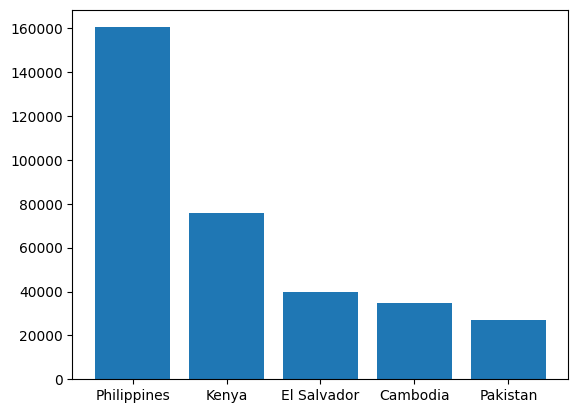

In [21]:
df = dane['country'].value_counts().head()
print(df, "\n\n")
plt.bar(df.index,df.values)

## Informacje o konkretnym kraju np. o Filipinach

In [22]:
Phil = dane[dane['country'] == 'Philippines'].copy()

Phil.info()
Phil.isnull().sum()
Phil.head()

<class 'pandas.core.frame.DataFrame'>
Index: 160441 entries, 51 to 670445
Data columns (total 20 columns):
 #   Column              Non-Null Count   Dtype  
---  ------              --------------   -----  
 0   id                  160441 non-null  int64  
 1   funded_amount       160441 non-null  float64
 2   loan_amount         160441 non-null  float64
 3   activity            160441 non-null  object 
 4   sector              160441 non-null  object 
 5   use                 160361 non-null  object 
 6   country_code        160441 non-null  object 
 7   country             160441 non-null  object 
 8   region              160360 non-null  object 
 9   currency            160441 non-null  object 
 10  partner_id          160441 non-null  float64
 11  posted_time         160441 non-null  object 
 12  disbursed_time      160441 non-null  object 
 13  funded_time         157607 non-null  object 
 14  term_in_months      160441 non-null  float64
 15  lender_count        160441 non-null  i

,id,funded_amount,loan_amount,activity,sector,use,country_code,country,region,currency,partner_id,posted_time,disbursed_time,funded_time,term_in_months,lender_count,tags,borrower_genders,repayment_interval,date
51,653092,175.0,175.0,Pigs,Agriculture,to buy piglets and feed,PH,Philippines,Liloy-Dela Paz,PHP,126.0,2014-01-02 00:25:40+00:00,2013-12-12 08:00:00+00:00,2014-01-02 01:42:51+00:00,8.0,6,NaN,female,irregular,2014-01-02
52,653149,175.0,175.0,Pigs,Agriculture,to purchase feed and vitamins for her pigs,PH,Philippines,"Tanjay, Negros Oriental",PHP,145.0,2014-01-02 04:18:30+00:00,2013-12-06 08:00:00+00:00,2014-01-02 07:47:28+00:00,8.0,7,NaN,female,irregular,2014-01-02
55,653123,700.0,700.0,General Store,Retail,"to buy additional items like eggs, charcoal, r...",PH,Philippines,"Brookes Point, Palawan",PHP,145.0,2014-01-02 02:18:02+00:00,2013-12-10 08:00:00+00:00,2014-01-02 03:26:10+00:00,5.0,2,NaN,female,irregular,2014-01-02
56,653338,575.0,575.0,Farming,Agriculture,to purchase fertilizers and other farm supplies,PH,Philippines,"Tanjay, Negros Oriental",PHP,145.0,2014-01-02 13:38:42+00:00,2013-12-05 08:00:00+00:00,2014-01-02 23:01:23+00:00,8.0,19,NaN,female,irregular,2014-01-02
65,653242,325.0,325.0,General Store,Retail,"to purchase sugar, coffee, coffee creamer, can...",PH,Philippines,"Sinippil, Cauayan City, Isabela",PHP,123.0,2014-01-02 09:13:05+00:00,2013-12-13 08:00:00+00:00,2014-01-02 17:50:06+00:00,7.0,11,volunteer_pick,female,irregular,2014-01-02


### Uzupełnianie brakujących danych
tags - wartość tekstowa


In [23]:
Phil['tags'].value_counts()

tags
#Parent, #Woman Owned Biz                                                                                                      7204
user_favorite                                                                                                                  5953
#Woman Owned Biz                                                                                                               4911
#Elderly                                                                                                                       2756
#Parent, #Repeat Borrower, #Woman Owned Biz                                                                                    2269
                                                                                                                               ... 
#Animals, #Repeat Borrower, #Parent, #Woman Owned Biz, #Animals, #Parent, #Woman Owned Biz, #Repeat Borrower, user_favorite       1
#Repeat Borrower, #Elderly, #Single, #Woman Owned Biz, #Woman Owned Biz

Wybór najczęściej występującego tagu

In [24]:
dominata = Phil['tags'].mode()
print("Dominująca kategoria:", dominata[0]) 

Dominująca kategoria: #Parent, #Woman Owned Biz


Uzupełnienie brakujących danych najpopulrniejszą wartością

In [25]:
Phil['tags'].fillna(dominata[0],inplace=True)
Phil.head()


C:\Users\mkowa\AppData\Local\Temp\ipykernel_10940\4107777757.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  Phil['tags'].fillna(dominata[0],inplace=True)


,id,funded_amount,loan_amount,activity,sector,use,country_code,country,region,currency,partner_id,posted_time,disbursed_time,funded_time,term_in_months,lender_count,tags,borrower_genders,repayment_interval,date
51,653092,175.0,175.0,Pigs,Agriculture,to buy piglets and feed,PH,Philippines,Liloy-Dela Paz,PHP,126.0,2014-01-02 00:25:40+00:00,2013-12-12 08:00:00+00:00,2014-01-02 01:42:51+00:00,8.0,6,"#Parent, #Woman Owned Biz",female,irregular,2014-01-02
52,653149,175.0,175.0,Pigs,Agriculture,to purchase feed and vitamins for her pigs,PH,Philippines,"Tanjay, Negros Oriental",PHP,145.0,2014-01-02 04:18:30+00:00,2013-12-06 08:00:00+00:00,2014-01-02 07:47:28+00:00,8.0,7,"#Parent, #Woman Owned Biz",female,irregular,2014-01-02
55,653123,700.0,700.0,General Store,Retail,"to buy additional items like eggs, charcoal, r...",PH,Philippines,"Brookes Point, Palawan",PHP,145.0,2014-01-02 02:18:02+00:00,2013-12-10 08:00:00+00:00,2014-01-02 03:26:10+00:00,5.0,2,"#Parent, #Woman Owned Biz",female,irregular,2014-01-02
56,653338,575.0,575.0,Farming,Agriculture,to purchase fertilizers and other farm supplies,PH,Philippines,"Tanjay, Negros Oriental",PHP,145.0,2014-01-02 13:38:42+00:00,2013-12-05 08:00:00+00:00,2014-01-02 23:01:23+00:00,8.0,19,"#Parent, #Woman Owned Biz",female,irregular,2014-01-02
65,653242,325.0,325.0,General Store,Retail,"to purchase sugar, coffee, coffee creamer, can...",PH,Philippines,"Sinippil, Cauayan City, Isabela",PHP,123.0,2014-01-02 09:13:05+00:00,2013-12-13 08:00:00+00:00,2014-01-02 17:50:06+00:00,7.0,11,volunteer_pick,female,irregular,2014-01-02


In [26]:
Phil.isnull().sum()

id                       0
funded_amount            0
loan_amount              0
activity                 0
sector                   0
use                     80
country_code             0
country                  0
region                  81
currency                 0
partner_id               0
posted_time              0
disbursed_time           0
funded_time           2834
term_in_months           0
lender_count             0
tags                     0
borrower_genders        80
repayment_interval       0
date                     0
dtype: int64

## Kodowanie etykiety na liczby
- Kodowanie etykiety (Label Encoding)
- Kodowanie 1 z n (One-Hot Encoding)
- Kodowanie zmiennej fikcyjnej (Dummy Encoding)


In [27]:
from sklearn import preprocessing

le = preprocessing.LabelEncoder()
Phil['region'] = le.fit_transform(Phil['region'])
Phil['region'].unique()

array([1608, 3225,  583, ...,  682,  293, 3508], shape=(3639,))

<Axes: xlabel='region', ylabel='Count'>

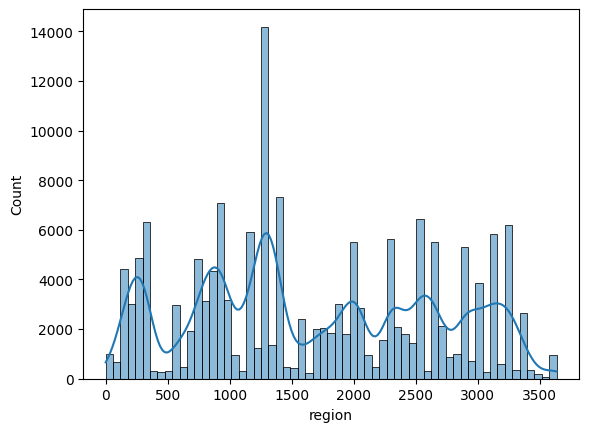

In [28]:
import seaborn as sns
sns.histplot(Phil['region'], kde=True)

In [29]:
mediana = Phil['region'].median()
print("Mediana regionu:", mediana)
# Phil['region'].fillna(mediana, inplace=True)
Phil.fillna({'region': mediana}, inplace=True)

Mediana regionu: 1421.0


## Usuwanie zbędnych cech (kolumn)
Dla przykładu uznamy, że kolumny: country_code, tags, date nie są nam do niczego potrzebne, więc je usunimey z danych:

In [30]:
Phil.drop(['country_code','tags','date'], axis=1, inplace=True)

In [31]:
Phil.info()

<class 'pandas.core.frame.DataFrame'>
Index: 160441 entries, 51 to 670445
Data columns (total 17 columns):
 #   Column              Non-Null Count   Dtype  
---  ------              --------------   -----  
 0   id                  160441 non-null  int64  
 1   funded_amount       160441 non-null  float64
 2   loan_amount         160441 non-null  float64
 3   activity            160441 non-null  object 
 4   sector              160441 non-null  object 
 5   use                 160361 non-null  object 
 6   country             160441 non-null  object 
 7   region              160441 non-null  int64  
 8   currency            160441 non-null  object 
 9   partner_id          160441 non-null  float64
 10  posted_time         160441 non-null  object 
 11  disbursed_time      160441 non-null  object 
 12  funded_time         157607 non-null  object 
 13  term_in_months      160441 non-null  float64
 14  lender_count        160441 non-null  int64  
 15  borrower_genders    160361 non-null  o

In [32]:
numeryczne = Phil.select_dtypes(include=['int64', 'float64'])
print(numeryczne.head())

        id  funded_amount  loan_amount  region  partner_id  term_in_months  \
51  653092          175.0        175.0    1608       126.0             8.0   
52  653149          175.0        175.0    3225       145.0             8.0   
55  653123          700.0        700.0     583       145.0             5.0   
56  653338          575.0        575.0    3225       145.0             8.0   
65  653242          325.0        325.0    2999       123.0             7.0   

    lender_count  
51             6  
52             7  
55             2  
56            19  
65            11  


                      id  funded_amount  loan_amount    region  partner_id  \
id              1.000000      -0.071565    -0.066855 -0.009644    0.030045   
funded_amount  -0.071565       1.000000     0.976438 -0.017707    0.045311   
loan_amount    -0.066855       0.976438     1.000000 -0.016795    0.035690   
region         -0.009644      -0.017707    -0.016795  1.000000   -0.024757   
partner_id      0.030045       0.045311     0.035690 -0.024757    1.000000   
term_in_months -0.084007       0.079585     0.105319 -0.008378   -0.052731   
lender_count   -0.249049       0.763405     0.747766 -0.023388    0.000424   

                term_in_months  lender_count  
id                   -0.084007     -0.249049  
funded_amount         0.079585      0.763405  
loan_amount           0.105319      0.747766  
region               -0.008378     -0.023388  
partner_id           -0.052731      0.000424  
term_in_months        1.000000      0.196910  
lender_count          0.196910      1.000000  

<Axes: >

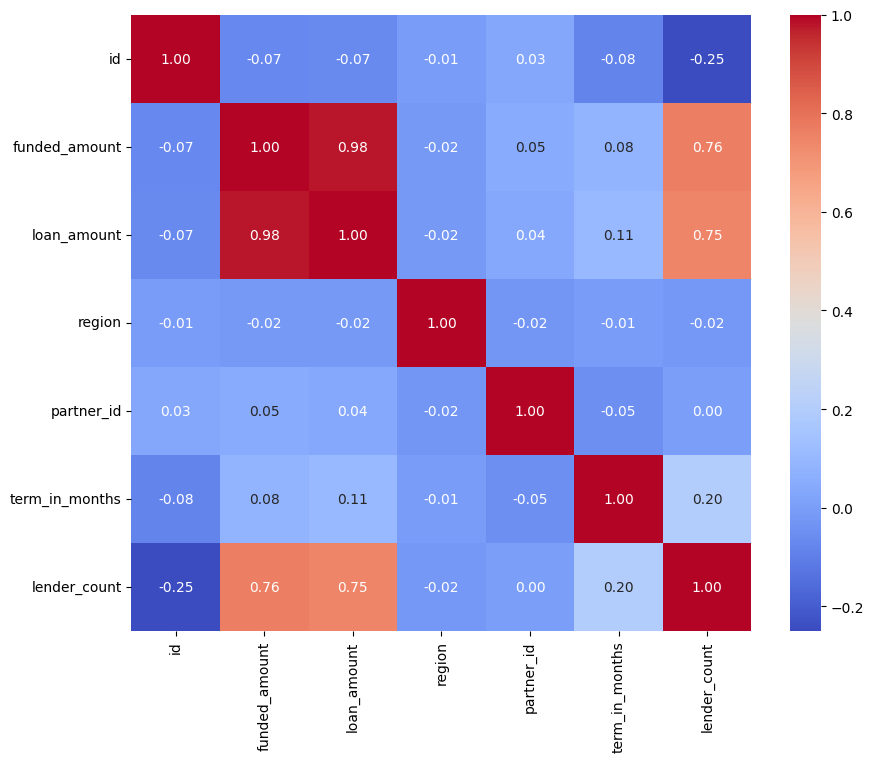

In [33]:
print(numeryczne.corr())
plt.figure(figsize=(10, 8))
sns.heatmap(numeryczne.corr(), annot=True, cmap='coolwarm', fmt='.2f')